In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [34]:
# Homework 7 - Euler's Method
# Using Euler's method, solve:

# ● dy/dx =-2y*cos(x), y(0) = 1
# ● over an interval, x∈[0,10pi] and a step size, h of [.01, .05, .15, .2, .25 … 1)
# ● average the y values of for each run of h
# ● compare/plot the error between each run
# ● compare the the values of y for x ≈ 15 (close to 15) for each run
# ● compare/plot the local error
                                                      
# You'll have 3 plots:
# ● one plot compare Euler's method for each value of h
# ● one plot for the average error between runs, avg error vs h
# ● one plot for the local error at x ≈ 15 for each run, local error vs h
# Write up a short explanation on what you're seeing and why


In [35]:
def f(x, y):
    return -2 * y * np.cos(x)

def exact_sol(x):
    return np.exp(-2 * np.sin(x))

x_start = 0
x_end = 10 * np.pi
y0 = 1


h_values = np.concatenate(([0.01, 0.05], np.arange(0.15, 1.0, 0.05)))
h_list = []
avg_y_values = []      
avg_global_errors = [] 
local_errors_at_15 = [] 
y_at_15_results = []   

In [38]:
for h in h_values:
    num_steps = int((x_end - x_start) / h)
    x = np.linspace(x_start, x_start + num_steps * h, num_steps + 1)
    y_euler = np.zeros(len(x))
    y_euler[0] = y0
    
    for i in range(num_steps):
        y_euler[i+1] = y_euler[i] + h * f(x[i], y_euler[i])

    #the avg y value
    avg_y_values.append(np.mean(y_euler))

    #avg global error
    y_true = exact_sol(x)
    avg_global_errors.append(np.mean(np.abs(y_true - y_euler)))

    # value at about 15
    idx_15 = (np.abs(x - 15)).argmin()
    y_at_15_results.append(y_euler[idx_15])

    #local error at about 15
    if idx_15 > 0:
        x_prev = x[idx_15 - 1]
        y_exact_prev = exact_sol(x_prev)
        euler_single_step = y_exact_prev + h * f(x_prev, y_exact_prev)
        local_err = np.abs(exact_sol(x[idx_15]) - euler_single_step)
        local_errors_at_15.append(local_err)
    
    h_list.append(h)

In [39]:
for i in range(len(h_list)):
    print("Run for h =", h_list[i])
    print("Average y value:", avg_y_values[i])
    print("Value at x approx 15:", y_at_15_results[i])
    print("Global Error:", avg_global_errors[i])
    print("Local Error at 15:", local_errors_at_15[i])
    print("")

Run for h = 0.01
Average y value: 1.91082742514553
Value at x approx 15: 0.23143958278779136
Global Error: 0.3685927534318778
Local Error at 15: 4.843845800489577e-05

Run for h = 0.05
Average y value: 1.0186021454567011
Value at x approx 15: 0.11986884462030582
Global Error: 1.2596139807940485
Local Error at 15: 0.0011426597547626316

Run for h = 0.15
Average y value: 0.3205052598252221
Value at x approx 15: 0.02092133869634508
Global Error: 1.9558394794393625
Local Error at 15: 0.008921749350462083

Run for h = 0.2
Average y value: 0.20456814776837223
Value at x approx 15: 0.007903260555351253
Global Error: 2.067650935655407
Local Error at 15: 0.014802065539590348

Run for h = 0.25
Average y value: 0.13633523621413846
Value at x approx 15: 0.0026622902905731154
Global Error: 2.1402882314396856
Local Error at 15: 0.021617323579471104

Run for h = 0.30000000000000004
Average y value: 0.09160157795514344
Value at x approx 15: 0.0007534138886943504
Global Error: 2.185167485643988
Local E

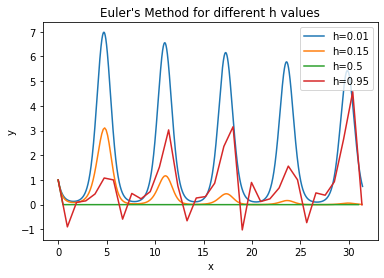

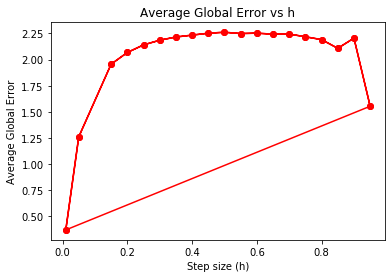

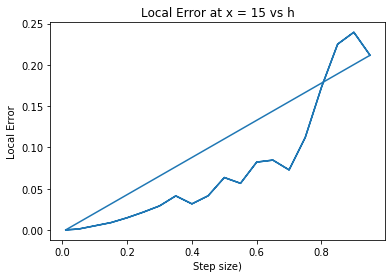

In [40]:
for h_val in [0.01, 0.15, 0.5, 0.95]:
    num_steps = int((x_end - x_start) / h_val)
    x_plot = np.linspace(x_start, x_start + num_steps * h_val, num_steps + 1)
    y_plot = np.zeros(len(x_plot))
    y_plot[0] = y0
    for i in range(num_steps):
        y_plot[i+1] = y_plot[i] + h_val * f(x_plot[i], y_plot[i])
    plt.plot(x_plot, y_plot, label=f'h={h_val}')

plt.title("Euler's Method for different h values")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

plt.plot(h_list, avg_global_errors, 'r-o')
plt.title("Average Global Error vs h")
plt.xlabel("Step size (h)")
plt.ylabel("Average Global Error")
plt.show()

plt.plot(h_list, local_errors_at_15)
plt.title("Local Error at x = 15 vs h")
plt.xlabel("Step size)")
plt.ylabel("Local Error")
plt.show()

In [41]:
k_val = 2.0
h_list = [0.01, 0.15, 0.5, 0.95, 1.2] 

print("Stability Analysis Check")

for h in h_list:
    max_lambda = -k_val 
    eigenvalue = 1 + (h * max_lambda)
    magnitude = abs(eigenvalue) 
    
    if magnitude <= 1:
        status = "Stable"
    else:
        status = "Unstable (Will Explode)"
        
    print(f"h = {h:.2f} | |λ| = {magnitude:.2f} | {status}")

Stability Analysis Check
h = 0.01 | |λ| = 0.98 | Stable
h = 0.15 | |λ| = 0.70 | Stable
h = 0.50 | |λ| = 0.00 | Stable
h = 0.95 | |λ| = 0.90 | Stable
h = 1.20 | |λ| = 1.40 | Unstable (Will Explode)


Explanation:
Smaller step sizes do a good job to getting close to the actual value of the function, but the approximation fails with larger step sizes, as it fails to capture the functions curvature. The linear growth in the global error shows that euler is a first order numerical method. Also, because the local truncation error grows quadratically with h in the beginning, it shows that small steps are necessary to maintain accuracy.

the output shows the math is correct because the solution is only stable when the step size h is 1 or smaller. If a step size is bigger than 1, like the h = 1.20 test, the error grows too fast and the calculation explodes.